# Final K-Means Model

This notebook creates the final K-Means clustering output for the customer segmentation project using the compact RobustScaler model input.


## Load Data

The modelling input is the final selected feature table from preprocessing. It contains `customer_id` plus 20 compact business features scaled with `RobustScaler`.


In [15]:
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

sys.path.append("../src")

from clustering import (
    calculate_clustering_metrics,
    create_cluster_profile,
    create_tsne_projection,
    fit_kmeans,
    get_cluster_summary,
    save_cluster_assignments,
    split_customer_features,
    validate_clustering_input,
)

df = pd.read_csv("../data/processed/selected_model_features.csv")
print(f"Loaded rows: {len(df):,}")
print(f"Loaded columns: {df.shape[1]}")


Loaded rows: 33,038
Loaded columns: 21


## Data Validation

Before modelling, the notebook checks that every customer appears once, that there are no missing values, and that all modelling columns are numeric.

In [16]:
validate_clustering_input(df)

row_count = len(df)
unique_customer_count = df["customer_id"].nunique()
duplicated_customer_count = df["customer_id"].duplicated().sum()
missing_value_count = df.isna().sum().sum()
non_numeric_columns = df.drop(columns=["customer_id"]).select_dtypes(exclude="number").columns.tolist()

print(f"Rows loaded: {row_count:,}")
print(f"Unique customer_id values: {unique_customer_count:,}")
print(f"Duplicated customer_id count: {duplicated_customer_count:,}")
print(f"Total missing values: {missing_value_count:,}")
print(f"Modelling columns are numeric: {len(non_numeric_columns) == 0}")

print("Input validation passed.")


Rows loaded: 33,038
Unique customer_id values: 33,038
Duplicated customer_id count: 0
Total missing values: 0
Modelling columns are numeric: True
Input validation passed.


## Prepare Modelling Data

The `customer_id` column is kept only for saving the final assignments. It is not used as a K-Means feature.

In [17]:
customer_ids, X = split_customer_features(df)

print(f"Customers: {len(customer_ids):,}")
print(f"Model features: {X.shape[1]}")


Customers: 33,038
Model features: 20


## Test K-Means Solutions

The baseline tests cluster counts from 2 to 10. The silhouette score uses a sample of up to 10,000 rows for performance.

In [18]:
k_values = range(2, 11)
metrics_rows = []

for k in k_values:
    print(f"Fitting K-Means with k={k}")
    kmeans, labels = fit_kmeans(X, n_clusters=k, random_state=42, n_init=50)
    metric_values = calculate_clustering_metrics(X, labels)
    metric_values["k"] = k
    metric_values["inertia"] = kmeans.inertia_

    metrics_rows.append(metric_values)

metrics = pd.DataFrame(metrics_rows)
metrics = metrics[[
    "k",
    "inertia",
    "silhouette_score",
    "calinski_harabasz_score",
    "davies_bouldin_score",
    "min_cluster_size",
    "max_cluster_size",
    "min_cluster_percentage",
    "max_cluster_percentage",
]]
metrics.to_csv("../outputs/kmeans_metrics.csv", index=False)

print("Saved metrics to outputs/kmeans_metrics.csv")
metrics


Fitting K-Means with k=2
Fitting K-Means with k=3
Fitting K-Means with k=4
Fitting K-Means with k=5
Fitting K-Means with k=6
Fitting K-Means with k=7
Fitting K-Means with k=8
Fitting K-Means with k=9
Fitting K-Means with k=10
Saved metrics to outputs/kmeans_metrics.csv


,k,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score,min_cluster_size,max_cluster_size,min_cluster_percentage,max_cluster_percentage
0,2,554300.385363,0.363965,8194.597040,1.309017,4141,28897,12.534052,87.465948
1,3,483341.741194,0.274196,7123.582439,1.299236,3100,25891,9.383135,78.367335
2,4,422520.970194,0.239049,7017.560946,1.584093,2987,20182,9.041104,61.087233
3,5,391157.562262,0.220848,6347.157519,1.539205,2619,18385,7.927235,55.648042
4,6,369350.588379,0.151830,5767.411270,1.854160,1745,9913,5.281797,30.004843
5,7,349882.927678,0.151242,5379.751504,1.786962,1070,9781,3.238695,29.605303
6,8,334230.129472,0.153991,5048.003991,1.768056,1072,10138,3.244748,30.685877
7,9,319723.139347,0.157711,4804.614503,1.751319,1073,8440,3.247775,25.546341
8,10,308072.114702,0.148022,4570.935726,1.728881,1066,6041,3.226588,18.285005


## Evaluation Charts

These charts compare compactness, separation, and cluster balance across the tested values of `k`.

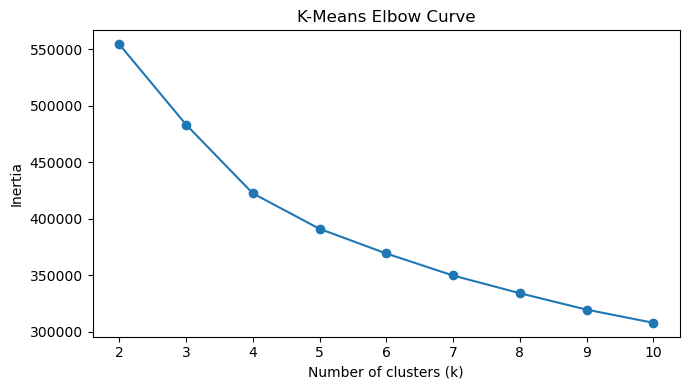

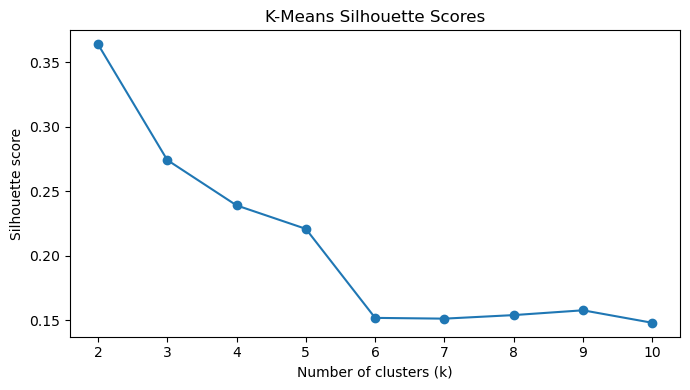

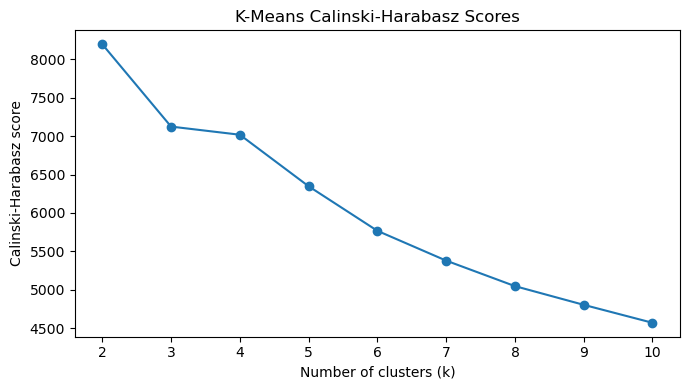

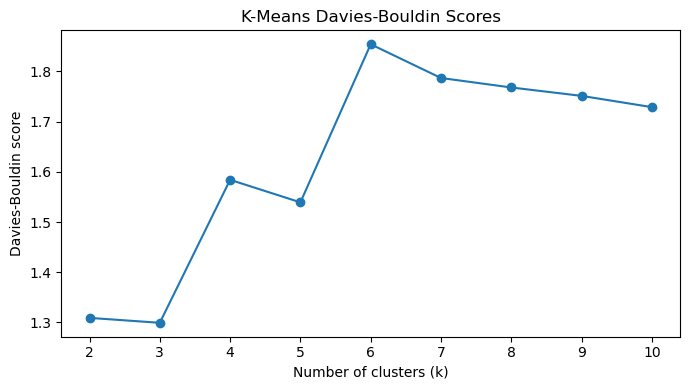

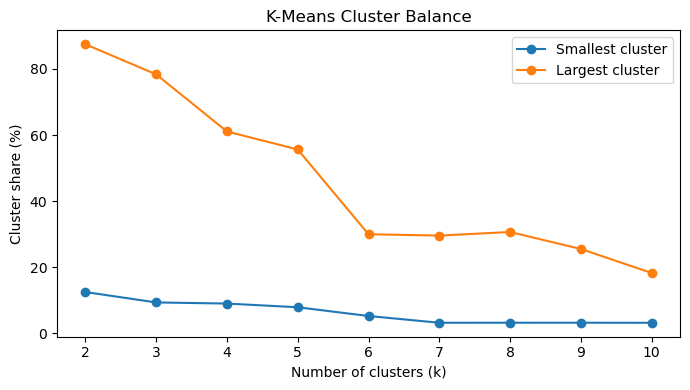

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(metrics["k"], metrics["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Curve")
plt.xticks(metrics["k"])
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(metrics["k"], metrics["silhouette_score"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-Means Silhouette Scores")
plt.xticks(metrics["k"])
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(metrics["k"], metrics["calinski_harabasz_score"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Calinski-Harabasz score")
plt.title("K-Means Calinski-Harabasz Scores")
plt.xticks(metrics["k"])
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(metrics["k"], metrics["davies_bouldin_score"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin score")
plt.title("K-Means Davies-Bouldin Scores")
plt.xticks(metrics["k"])
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(metrics["k"], metrics["min_cluster_percentage"], marker="o", label="Smallest cluster")
plt.plot(metrics["k"], metrics["max_cluster_percentage"], marker="o", label="Largest cluster")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Cluster share (%)")
plt.title("K-Means Cluster Balance")
plt.xticks(metrics["k"])
plt.legend()
plt.tight_layout()
plt.show()


## Final k Choice

The final segmentation uses `SELECTED_K = 5`. This choice is supported by the K-Means baseline, model comparison, robustness checks, and the feature/scaler sensitivity review. The final output is regenerated from the compact RobustScaler feature table.


In [20]:
SELECTED_K = 5
print(f"Selected k: {SELECTED_K}")


Selected k: 5


## Final Model

The final model is fitted on the selected modelling features, not on PCA components. The saved output contains every customer and their assigned cluster.


In [21]:
final_kmeans, final_labels = fit_kmeans(X, n_clusters=SELECTED_K, random_state=42, n_init=50)

cluster_assignments = save_cluster_assignments(
    customer_ids,
    final_labels,
    "../outputs/customer_clusters.csv",
)

print("Saved cluster assignments to outputs/customer_clusters.csv")
print(cluster_assignments.head())


Saved cluster assignments to outputs/customer_clusters.csv
   customer_id  cluster
0            3        1
1            4        2
2            5        1
3            7        3
4            8        3


## PCA Visualization

PCA is used only for a two-dimensional visual inspection of the clusters. K-Means is not trained on the PCA components in this baseline.

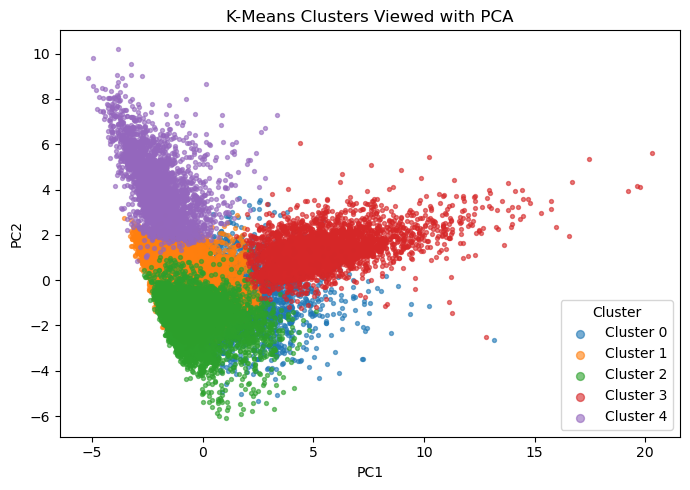

PCA explained variance ratio: [0.26982903 0.15383622]


In [22]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X)
cluster_ticks = sorted(cluster_assignments["cluster"].unique())

plt.figure(figsize=(7, 5))
for cluster in cluster_ticks:
    cluster_mask = final_labels == cluster
    plt.scatter(
        pca_components[cluster_mask, 0],
        pca_components[cluster_mask, 1],
        color=plt.cm.tab10(int(cluster)),
        label=f"Cluster {cluster}",
        s=8,
        alpha=0.6,
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters Viewed with PCA")
plt.legend(title="Cluster", markerscale=2, frameon=True)
plt.tight_layout()
plt.show()

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")


## t-SNE Visualization

PCA is a linear projection, so it may miss more complex cluster structure. t-SNE is added here only as another visual check of the existing K-Means clusters.

The K-Means model was not trained on t-SNE components. A sample is used because t-SNE can be slow on a large dataset.

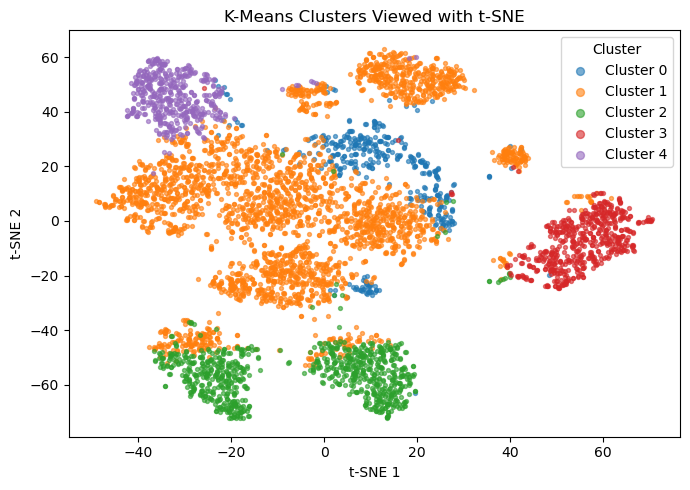

t-SNE sample rows: 5,000


In [23]:
tsne_df = create_tsne_projection(
    X,
    final_labels,
    customer_ids=customer_ids,
    sample_size=5000,
    random_state=42,
)
tsne_cluster_ticks = sorted(tsne_df["cluster"].unique())

plt.figure(figsize=(7, 5))
for cluster in tsne_cluster_ticks:
    cluster_points = tsne_df[tsne_df["cluster"] == cluster]
    plt.scatter(
        cluster_points["tsne_1"],
        cluster_points["tsne_2"],
        color=plt.cm.tab10(int(cluster)),
        label=f"Cluster {cluster}",
        s=8,
        alpha=0.6,
    )
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("K-Means Clusters Viewed with t-SNE")
plt.legend(title="Cluster", markerscale=2, frameon=True)
plt.tight_layout()
plt.show()

print(f"t-SNE sample rows: {len(tsne_df):,}")


## Final Validation

The final checks confirm that the saved cluster assignment file has one valid cluster label for every input customer.

In [24]:
saved_clusters = pd.read_csv("../outputs/customer_clusters.csv")
cluster_size_table = get_cluster_summary(saved_clusters["cluster"])
row_count_matches = len(saved_clusters) == len(df)

print(f"Rows in customer_clusters.csv: {len(saved_clusters):,}")
print(f"Unique customer_id values: {saved_clusters['customer_id'].nunique():,}")
print(f"Missing cluster values: {saved_clusters['cluster'].isna().sum():,}")
print("Cluster size table:")
print(cluster_size_table.to_string(index=False))
print(f"Output row count matches input row count: {row_count_matches}")

if not row_count_matches:
    raise ValueError("Cluster output row count does not match the input row count.")

if saved_clusters["customer_id"].duplicated().sum() > 0:
    raise ValueError("Cluster output contains duplicated customer_id values.")

if saved_clusters["cluster"].isna().sum() > 0:
    raise ValueError("Cluster output contains missing cluster values.")


Rows in customer_clusters.csv: 33,038
Unique customer_id values: 33,038
Missing cluster values: 0
Cluster size table:
 cluster  count  percentage
       0   2619    7.927235
       1  18385   55.648042
       2   5538   16.762516
       3   3552   10.751256
       4   2944    8.910951
Output row count matches input row count: True


## Initial Cluster Profiling

The previous sections created the first K-Means baseline with `SELECTED_K = 5`. Now the goal is to understand what each cluster represents.

For profiling, this section uses interpretable customer features from `customer_features_info.csv`, not the scaled model input used by K-Means. The cluster names and descriptions are still provisional and should be reviewed more carefully in the next phase.

In [25]:
features_info = pd.read_csv("../data/processed/customer_features_info.csv")
clusters = pd.read_csv("../outputs/customer_clusters.csv")

profiling_df = clusters.merge(features_info, on="customer_id", how="left")

profiling_rows = len(profiling_df)
profiling_unique_customers = profiling_df["customer_id"].nunique()
profiling_duplicate_customers = profiling_df["customer_id"].duplicated().sum()
profiling_missing_clusters = profiling_df["cluster"].isna().sum()
preserved_all_customers = len(profiling_df) == len(clusters)

print(f"Rows in profiling dataset: {profiling_rows:,}")
print(f"Unique customer_id values: {profiling_unique_customers:,}")
print(f"Duplicated customer_id count: {profiling_duplicate_customers:,}")
print(f"Missing cluster values: {profiling_missing_clusters:,}")
print(f"All clustered customers preserved: {preserved_all_customers}")

if profiling_duplicate_customers > 0:
    raise ValueError("Profiling dataset contains duplicated customer_id values.")

if profiling_missing_clusters > 0:
    raise ValueError("Profiling dataset contains missing cluster values.")

if len(profiling_df) != len(clusters):
    raise ValueError("Profiling merge changed the number of customer rows.")


Rows in profiling dataset: 33,038
Unique customer_id values: 33,038
Duplicated customer_id count: 0
Missing cluster values: 0
All clustered customers preserved: True


### Profile Summary

The profile table compares each cluster using readable customer-level features. Means and medians are both included because some customer behavior variables can be skewed.

In [26]:
profile_columns = [
    "age",
    "customer_tenure",
    "total_lifetime_spend",
    "lifetime_total_distinct_products",
    "percentage_of_products_bought_promotion",
    "number_complaints",
    "distinct_stores_visited",
    "has_loyalty_card",
    "total_children_home",
    "has_children",
]
profile_columns = [column for column in profile_columns if column in profiling_df.columns]

cluster_profile = create_cluster_profile(
    profiling_df,
    cluster_column="cluster",
    columns=profile_columns,
)
cluster_profile.to_csv("../outputs/kmeans_cluster_profile_summary.csv", index=False)

print(f"Profile columns used: {profile_columns}")
print("Saved profile summary to outputs/kmeans_cluster_profile_summary.csv")
cluster_profile


Profile columns used: ['age', 'customer_tenure', 'total_lifetime_spend', 'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 'number_complaints', 'distinct_stores_visited', 'has_loyalty_card', 'total_children_home', 'has_children']
Saved profile summary to outputs/kmeans_cluster_profile_summary.csv


,cluster,age_mean,age_median,customer_tenure_mean,customer_tenure_median,total_lifetime_spend_mean,total_lifetime_spend_median,lifetime_total_distinct_products_mean,lifetime_total_distinct_products_median,percentage_of_products_bought_promotion_mean,...,number_complaints_mean,number_complaints_median,distinct_stores_visited_mean,distinct_stores_visited_median,has_loyalty_card_mean,has_loyalty_card_median,total_children_home_mean,total_children_home_median,has_children_mean,has_children_median
0,0,60.438293,61.0,14.098893,14.0,10334.531119,9704.0,148.506300,125.0,0.451232,...,0.978939,1.0,3.744599,4.0,0.676594,1.0,1.567916,1.0,0.843452,1.0
1,1,56.427556,56.0,13.801197,14.0,25883.313625,22029.0,147.544738,125.0,0.382243,...,0.969858,1.0,3.297581,3.0,0.610715,1.0,1.647543,2.0,0.852760,1.0
2,2,60.564293,61.0,13.212893,14.0,15564.080354,15623.0,103.634706,100.0,0.133350,...,0.662247,1.0,3.419337,3.0,0.578007,1.0,1.923374,2.0,0.956302,1.0
3,3,59.460102,59.0,11.856700,12.0,22720.375000,22726.0,106.633727,100.0,0.268809,...,1.075309,1.0,1.643182,1.0,0.492117,0.0,0.656214,0.0,0.473536,0.0
4,4,60.420102,61.0,15.720448,16.0,37485.913043,37309.5,294.022418,297.0,0.214889,...,0.975770,1.0,3.213795,3.0,0.673573,1.0,6.423234,6.0,1.000000,1.0


### Spending Share Profile

This table checks which product groups have the highest average spending share inside each cluster.

In [27]:
share_columns = [column for column in profiling_df.columns if column.startswith("share_")]

cluster_spending_shares = profiling_df.groupby("cluster")[share_columns].mean().reset_index()
cluster_spending_shares.to_csv("../outputs/kmeans_cluster_spending_shares.csv", index=False)

print(f"Spending share columns used: {share_columns}")
print("Saved spending share profile to outputs/kmeans_cluster_spending_shares.csv")
cluster_spending_shares


Spending share columns used: ['share_groceries', 'share_electronics', 'share_vegetables', 'share_nonalcohol_drinks', 'share_alcohol_drinks', 'share_meat', 'share_fish', 'share_hygiene', 'share_videogames', 'share_petfood']
Saved spending share profile to outputs/kmeans_cluster_spending_shares.csv


,cluster,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
0,0,0.437805,0.130586,0.051953,0.039062,0.047111,0.095093,0.066338,0.075056,0.024993,0.042405
1,1,0.759408,0.066907,0.024164,0.015720,0.023996,0.033304,0.025456,0.030667,0.009535,0.015220
2,2,0.574266,0.098822,0.127462,0.036605,0.021219,0.008265,0.007382,0.095592,0.011789,0.023943
3,3,0.364397,0.374786,0.014346,0.025402,0.048197,0.041288,0.037542,0.015963,0.073905,0.014895
4,4,0.652140,0.138982,0.023003,0.022919,0.042290,0.041825,0.036926,0.026407,0.011752,0.010540


### Profile Plots

These simple plots focus on spend level, promotion sensitivity, and loyalty rate because they are useful first checks for customer segmentation.

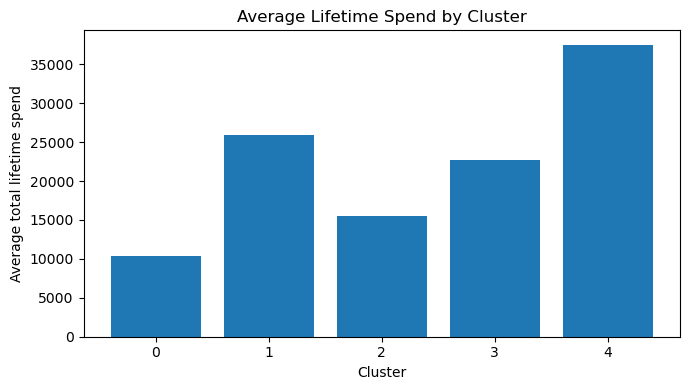

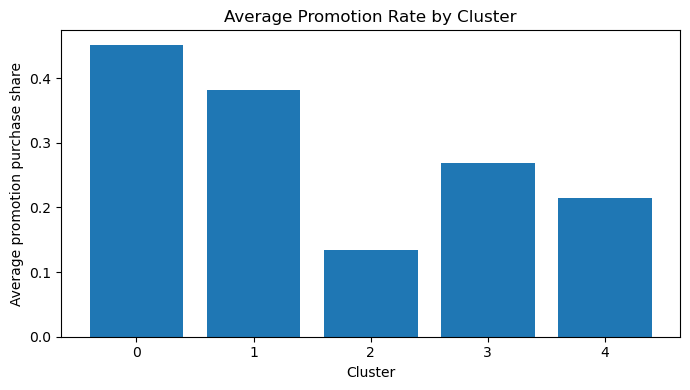

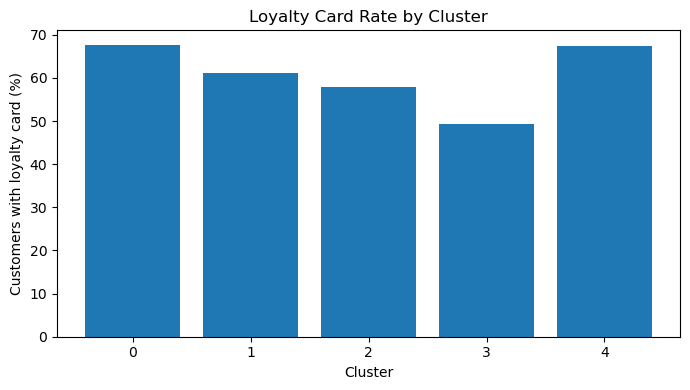

In [28]:
spend_by_cluster = profiling_df.groupby("cluster")["total_lifetime_spend"].mean()
promotion_by_cluster = profiling_df.groupby("cluster")["percentage_of_products_bought_promotion"].mean()
loyalty_by_cluster = profiling_df.groupby("cluster")["has_loyalty_card"].mean() * 100

plt.figure(figsize=(7, 4))
plt.bar(spend_by_cluster.index.astype(str), spend_by_cluster.values)
plt.xlabel("Cluster")
plt.ylabel("Average total lifetime spend")
plt.title("Average Lifetime Spend by Cluster")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(promotion_by_cluster.index.astype(str), promotion_by_cluster.values)
plt.xlabel("Cluster")
plt.ylabel("Average promotion purchase share")
plt.title("Average Promotion Rate by Cluster")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(loyalty_by_cluster.index.astype(str), loyalty_by_cluster.values)
plt.xlabel("Cluster")
plt.ylabel("Customers with loyalty card (%)")
plt.title("Loyalty Card Rate by Cluster")
plt.tight_layout()
plt.show()


### Provisional Interpretation

These descriptions are early profiling notes, not final segment names. The next phase should validate whether these groups are stable, useful, and meaningful for business decisions.

**Cluster 0**

- Appears to have older customers with below-average lifetime spend.
- Shows above-average promotion usage and the highest average number of stores visited.
- Seems less grocery-dominated than most clusters, with more spread across electronics and meat.

**Cluster 1**

- Appears to be the highest-value cluster, with the highest average lifetime spend and most distinct products.
- Shows the highest average tenure and the highest loyalty-card rate.
- Seems strongly grocery-focused and has the highest average number of children at home.

**Cluster 2**

- Shows lower-than-average lifetime spend and a low promotion purchase share.
- Appears to have many customers with children, but fewer distinct products than clusters 0 and 1.
- Seems mainly grocery-focused, with vegetables also more visible than in several other clusters.

**Cluster 3**

- Appears to contain younger customers with shorter tenure than the overall average.
- Shows the highest promotion purchase share and the highest average complaint count.
- Seems grocery-heavy, but with lower loyalty-card usage than clusters 0, 1, and 2.

**Cluster 4**

- Appears to have fewer children at home and the lowest loyalty-card rate.
- Shows the lowest average number of stores visited.
- Seems more focused on electronics than the other clusters, with groceries still important but less dominant.